In [2]:
pwd

'/Users/ashlynjorgenson/Desktop/python_decal_fa25/ashlyn/homework9'

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
df=pd.read_csv('../../course_assignments/homework9/noisy_curvefit_data.csv')
print(df.shape) # (100, 6). 100 rows, 6 columns
print(df.head()) # x, y_noise_1, y_noise_2, y_noise_3, y_noise_4, y_noise_5

(100, 6)
          x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
0 -1.000000  11.624419   8.296963  12.201067   7.811725   3.155566
1 -0.929293  10.377466   9.674440  12.198084   8.275006   7.518855
2 -0.858586  10.585100   9.251983  13.186565  12.926586   9.963630
3 -0.787879  10.913928   7.786344  12.552304  11.832379   9.625801
4 -0.717172   8.640287   8.551869   4.741432   8.790834   6.624113


In [3]:
print(df.tail())

           x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
95  5.717172  -1.411918   0.822231  -2.027132  -1.825106   2.746147
96  5.787879   0.344879  -1.718956   2.747559  -6.803779  -5.137472
97  5.858586   0.307133   0.353528   0.967976   5.461567  -0.905616
98  5.929293   0.048657   0.159961   2.482130  -0.414616  -4.334548
99  6.000000  -0.193438  -2.244792   1.930035   4.992414  -6.872850


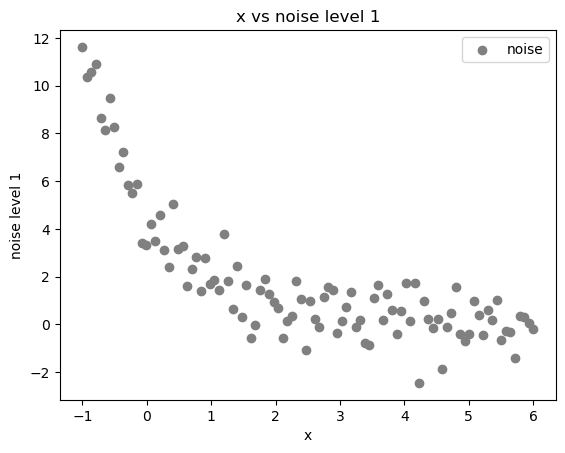

In [4]:
x=df["x"]
y=df["y_noise_1"]
plt.scatter(x,y,label="noise", color="grey")
plt.title("x vs noise level 1")
plt.xlabel("x")
plt.ylabel("noise level 1")
plt.legend()
plt.show()

In [5]:
def model(x, A, k):
    return A * np.exp(-k * x)
p0=[1,1]
y_noise_1=y
popt, pcov = curve_fit(model, x, y_noise_1, p0=p0)
A_fit, k_fit = popt
print(f"Fit: y = {A_fit:.2f} * e^(-{k_fit:.2f}*x)")

Fit: y = 4.71 * e^(-0.92*x)


In [6]:
residuals=y_noise_1 - model(x, A_fit, k_fit)
chi2=np.sum(residuals**2)
dof=len(x)-len(popt)
chi2_reduced=chi2/dof

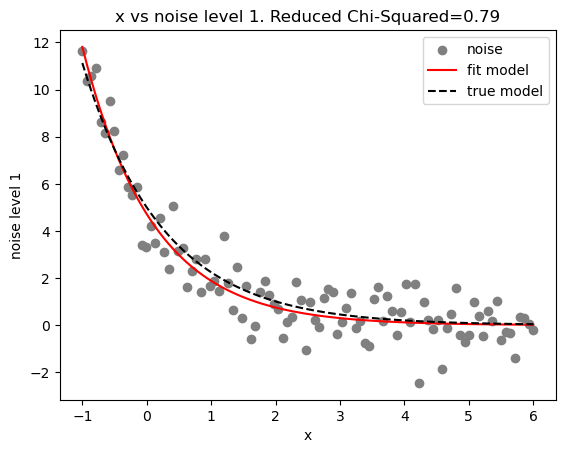

Reduced Chi-Squared: 0.79


In [21]:
x=df["x"]
y=df["y_noise_1"]
e=2.7182818
plt.scatter(x,y,label="noise", color="grey")
plt.plot(x, A_fit * e**(-k_fit*x), color="red", label="fit model")
plt.title("x vs noise level 1. Reduced Chi-Squared=0.79")
plt.xlabel("x")
plt.ylabel("noise level 1")
plt.plot(x, model(x, 5, 0.8), linestyle="--", color="black", label="true model")
plt.legend()
plt.show()
print(f"Reduced Chi-Squared: {chi2_reduced:.2f}")

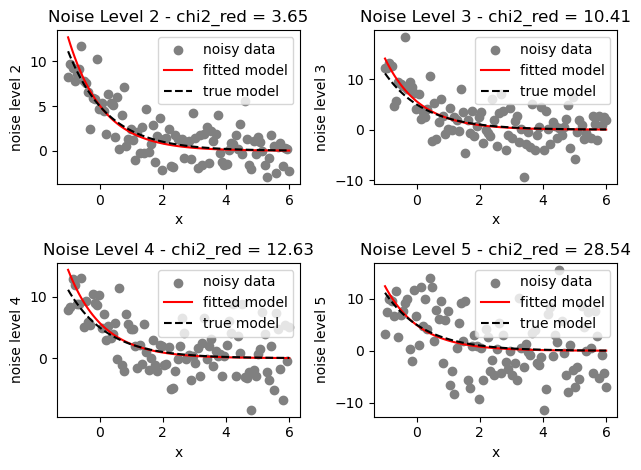

In [26]:
def fit_model(x,y):
    p0=[1,1]
    popt, pcov = curve_fit(model, x, y, p0=p0)
    A_fit, k_fit = popt

    residuals = y - model(x, A_fit, k_fit)
    chi2=np.sum(residuals**2)
    dof=len(x)-len(popt)
    chi2_reduced=chi2/dof
    return A_fit, k_fit, chi2_reduced

noise_arrays=[
    df["y_noise_2"],
    df["y_noise_3"],
    df["y_noise_4"],
    df["y_noise_5"]
]

fig, axes = plt.subplots(2,2)
for ax, (noise_level, y_noise) in zip(
    axes.ravel(),
    enumerate(noise_arrays, start=2)
):
    A_fit, k_fi, chi2_reduced=fit_model(df["x"],y_noise)
    ax.scatter(df["x"], y_noise, color="grey", label="noisy data")

    ax.plot(df["x"], model(df["x"], A_fit, k_fit),
    color="red", label="fitted model")

    ax.plot(df["x"], model(df["x"], 5, 0.8),
    linestyle="--", color="black", label="true model")

    ax.set_title(f"Noise Level {noise_level} - chi2_red = {chi2_reduced:.2f}")

    ax.set_xlabel("x")
    ax.set_ylabel(f"noise level {noise_level}")

    ax.legend()
plt.tight_layout()
plt.show()

In [27]:
# as noise level increases, the red and black lines get closer together. High noise levels can disrupt the information of the data and the best-fit line will be closer to he shape of the true model
# as noise increases, reduced chi-squared increases because chi2 measures how far the data points are from the model, so more noise means the data is farther from the true model

In [33]:
results_df=pd.DataFrame({
    "Noise Level": [1, 2, 3, 4, 5],
    "A fit": [
        fit_model(df["x"], df["y_noise_1"])[0],
        fit_model(df["x"], df["y_noise_2"])[0],
        fit_model(df["x"], df["y_noise_3"])[0],
        fit_model(df["x"], df["y_noise_4"])[0],
        fit_model(df["x"], df["y_noise_5"])[0],
    ],
    "k fit": [
        fit_model(df["x"], df["y_noise_1"])[1],
        fit_model(df["x"], df["y_noise_2"])[1],
        fit_model(df["x"], df["y_noise_3"])[1],
        fit_model(df["x"], df["y_noise_4"])[1],
        fit_model(df["x"], df["y_noise_5"])[1],
    ],
    "Reduced chi-squared": [
        fit_model(df["x"], df["y_noise_1"])[2],
        fit_model(df["x"], df["y_noise_2"])[2],
        fit_model(df["x"], df["y_noise_3"])[2],
        fit_model(df["x"], df["y_noise_4"])[2],
        fit_model(df["x"], df["y_noise_5"])[2],
    ]
})
print(results_df.head())   

   Noise Level     A fit     k fit  Reduced chi-squared
0            1  4.714814  0.918308             0.790673
1            2  5.063889  0.730396             3.649382
2            3  5.609396  0.870372            10.410207
3            4  5.738727  0.725965            12.626832
4            5  4.943458  0.695012            28.538124


In [35]:
results_df.to_csv("noisy_parameters.csv", index=False)